# Baco-Pangeome of Klebsiella 

## Data Preparation

This notebook analyzes pre-extracted AnnData objects containing Bacformer protein embeddings at the gene level.

**To generate the AnnData object, run the extraction script:**

```bash
# From the workspace root
uv run python -m bacotype.pp.extract_anndata_with_bacformer_protein_embeddings \
    --clonal-group CG258 \
    --n-samples 20 \
    --output cg258_n20_bacformer_anndata.h5ad \
    --seed 42
```

**What the extraction script does:**
- Filters metadata by clonal group (e.g., CG258)
- Randomly samples n genomes from the filtered set
- Loads Bacformer protein embeddings from PyTorch .pt files
- Explodes embeddings from sample-level to gene-level (~5000 genes per sample)
- Merges with selected metadata columns (Clonal group, Sublineage, K_locus, K_type)
- Creates AnnData object with embeddings in X and metadata in obs
- Saves to .h5ad format (~1-2GB for 20 samples)

**Memory efficiency:**
Running the extraction separately avoids memory issues on login nodes. The extraction script handles memory cleanup automatically.

In [ ]:
# Imports
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import random

from pathlib import Path
from tqdm import tqdm

/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
  """ Class for doing community detection using the Leiden algorithm.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:305: SyntaxWarning: invalid escape sequence '\s'
  """ Optimise the given partitions simultaneously.


In [ ]:
# Load pre-extracted AnnData from .h5ad file
# This file was generated using extract_anndata_with_bacformer_protein_embeddings.py
from bacotype.data_paths import data

anndata_dir = data.klebsiella_anndata_dir
anndata_file = anndata_dir / "cg258_n20_seed42_bacformer_anndata.h5ad"

print(f"Loading AnnData from {anndata_file}")
adata = ad.read_h5ad(anndata_file)

# Display summary information
print(f"\nLoaded AnnData with {adata.n_obs:,} observations (genes)")
print(f"Number of unique samples: {adata.obs['sample_id'].nunique()}")
print(f"Embedding dimensions: {adata.n_vars}")
print(f"\nAnnData structure:")
print(f"  - X shape: {adata.X.shape}")
print(f"  - obs shape: {adata.obs.shape}")
print(f"  - obs columns: {adata.obs.columns.tolist()}")
print(f"\nProcessing parameters:")
for key, value in adata.uns['processing_params'].items():
    print(f"  - {key}: {value}")
print(f"\nSample metadata stored in adata.uns['sample_metadata']: {adata.uns['sample_metadata'].shape}")

Metadata shape before indexing: (88303, 158)
Metadata columns: ['Sample', 'is_kpsc', 'kpsc_final_list', 'is_refseq', 'is_nctc', 'species', 'species_match', 'Clonal group', 'LINcode', 'Phylogroup', 'Sublineage', 'scgST', 'contig_count', 'N50', 'largest_contig', 'total_size', 'ambiguous_bases', 'QC_warnings', 'ST', 'gapA', 'infB', 'mdh', 'pgi', 'phoE', 'rpoB', 'tonB', 'YbST', 'Yersiniabactin', 'ybtS', 'ybtX', 'ybtQ', 'ybtP', 'ybtA', 'irp2', 'irp1', 'ybtU', 'ybtT', 'ybtE', 'fyuA', 'spurious_ybt_hits', 'CbST', 'Colibactin', 'clbA', 'clbB', 'clbC', 'clbD', 'clbE', 'clbF', 'clbG', 'clbH', 'clbI', 'clbL', 'clbM', 'clbN', 'clbO', 'clbP', 'clbQ', 'spurious_clb_hits', 'AbST', 'Aerobactin', 'iucA', 'iucB', 'iucC', 'iucD', 'iutA', 'spurious_abst_hits', 'SmST', 'Salmochelin', 'iroB', 'iroC', 'iroD', 'iroN', 'spurious_smst_hits', 'RmST', 'RmpADC', 'rmpA', 'rmpD', 'rmpC', 'spurious_rmst_hits', 'virulence_score', 'spurious_virulence_hits', 'rmpA2', 'AGly_acquired', 'Col_acquired', 'Fcyn_acquired', 'Fl

In [ ]:
# Subsample 20 genomes - that is 20 * ~5000 = ~100,000 genes
# Get unique sample IDs and randomly sample 20
unique_sample_ids = adata.obs['sample_id'].unique().tolist()
# Subsample 20 that are all part of Clonal group CG258
cg258_samples = adata.obs[adata.obs['Clonal group'] == 'CG258']['sample_id'].unique().tolist()
cg258_genome_ids = random.sample(cg258_samples, 20)

print(f"Sampled {len(cg258_genome_ids)} genomes: {cg258_genome_ids[:5]}...")

# Subset the AnnData object to only genes from these 20 samples
adata_cg258_sampled_subset = adata[adata.obs['sample_id'].isin(cg258_genome_ids)].copy()

print(f"Subsetted AnnData shape: {adata_cg258_sampled_subset.shape}")
print(f"Number of unique samples in subset: {adata_cg258_sampled_subset.obs['sample_id'].nunique()}")

# Compute neighbors on the embedding space (X contains the 960-dim embeddings)
sc.pp.neighbors(adata_cg258_sampled_subset, n_neighbors=15, n_pcs=0)  # n_pcs=0 means use X directly

# Compute UMAP
sc.tl.umap(adata_cg258_sampled_subset)

print("UMAP computed successfully!")
print(f"UMAP coordinates shape: {adata_cg258_sampled_subset.obsm['X_umap'].shape}")

Sampled 20 genomes: ['SAMN08720217', 'SAMEA104367915', 'SAMEA3515151', 'SAMN07447452', 'SAMN06438460']...
Subsetted AnnData shape: (106499, 960)
Number of unique samples in subset: 20


/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


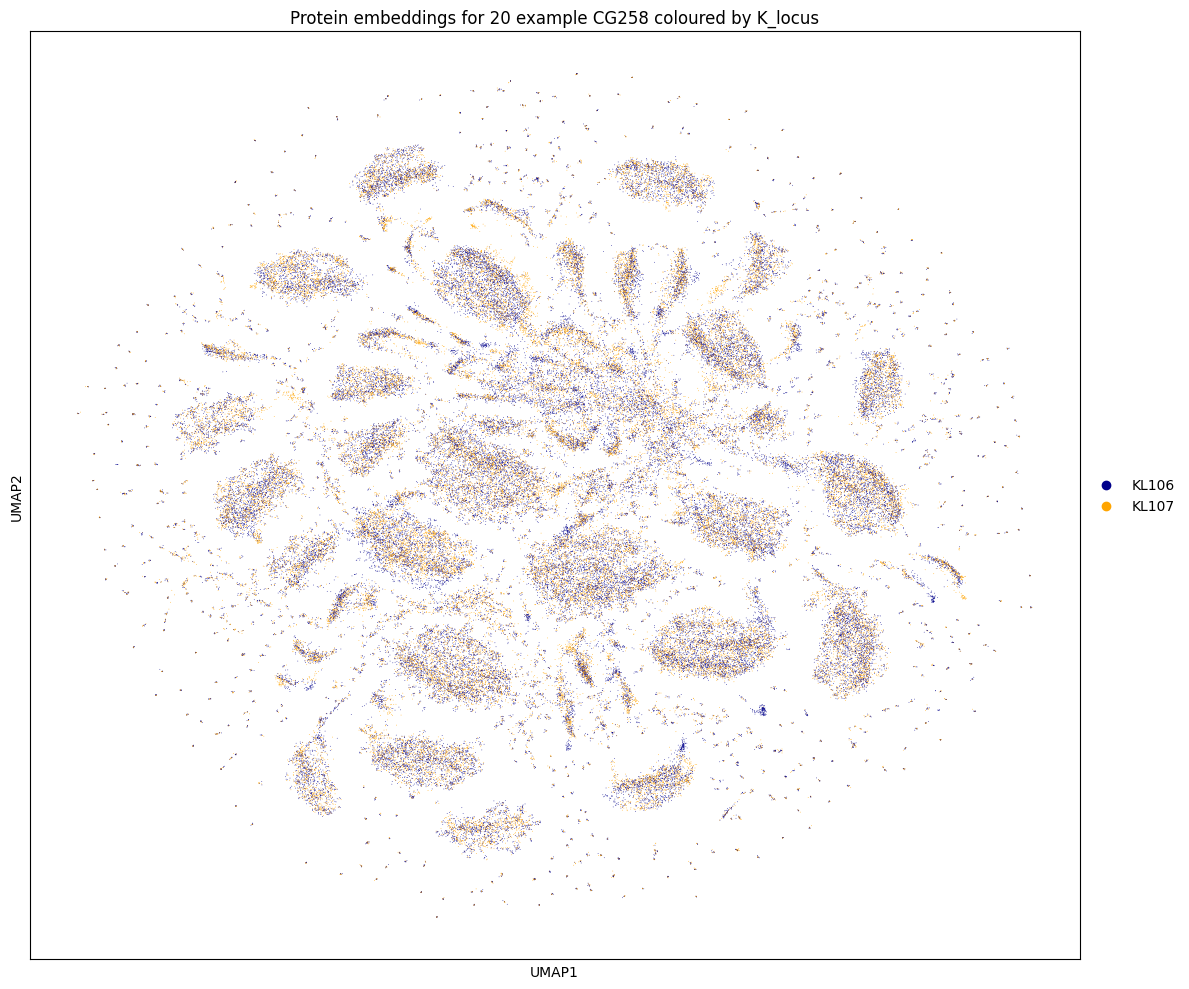


Total points plotted: 101759
Number of samples (colors): 19

K_locus distribution:
K_locus
KL106    53336
KL107    48423
Name: count, dtype: int64


In [ ]:
# Plot UMAP colored by K_locus with custom colors
import matplotlib.pyplot as plt

# Define custom color palette for K_locus
k_locus_palette = {
    'KL106': 'darkblue',
    'KL107': 'orange',  # fluoro yellow (full-bright yellow)
    'KL23': 'red'
}

# Remove any K_locus = 'KL23' from the subset
adata_cg258_sampled_subset = adata_cg258_sampled_subset[adata_cg258_sampled_subset.obs['K_locus'] != 'KL23']

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP colored by K_locus with custom palette and set the plot title
sc.pl.umap(
    adata_cg258_sampled_subset, 
    color='K_locus', 
    palette=k_locus_palette, 
    ax=ax, 
    show=False, 
    legend_loc='right margin',
    title='Protein embeddings for 20 example CG258 coloured by K_locus'
)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal points plotted: {adata_cg258_sampled_subset.shape[0]}")
print(f"Number of samples (colors): {adata_cg258_sampled_subset.obs['sample_id'].nunique()}")
print(f"\nK_locus distribution:")
print(adata_cg258_sampled_subset.obs['K_locus'].value_counts())

In [ ]:
# Lets leiden cluster these embeddings and extract the clusters with > 95% purity or < 5% purity for each K_locus
# Run Leiden clustering on the already-computed neighbors
sc.tl.leiden(adata_cg258_sampled_subset, resolution=0.5)

# Plot UMAP colored by leiden cluster
sc.pl.umap(
    adata_cg258_sampled_subset,
    color='leiden',
    ax=ax, show=False)

NameError: name 'sc' is not defined

In [ ]:
# Get cluster assignments and K_locus annotations
cluster_klocus = pd.DataFrame({
    'cluster': adata_cg258_sampled_subset.obs['leiden'],
    'K_locus': adata_cg258_sampled_subset.obs['K_locus']
})
# Count K_locus per cluster
cluster_counts = cluster_klocus.groupby(['cluster', 'K_locus']).size().unstack(fill_value=0)

# Calculate KL106/KL107 ratio
cluster_counts['ratio'] = cluster_counts['KL106'] / cluster_counts['KL107']
cluster_counts['total'] = cluster_counts['KL106'] + cluster_counts['KL107']

print(cluster_counts)

In [ ]:
# Select clusters with extreme ratios
selected_clusters = cluster_counts[
    (cluster_counts['ratio'] > 0.95) | (cluster_counts['ratio'] < 0.05)
].index.tolist()

print(f"Selected {len(selected_clusters)} clusters with extreme KL106/KL107 ratios:")
print(f"Cluster IDs: {selected_clusters}")

# Filter the AnnData object to only these clusters
adata_selected = adata_cg258_sampled_subset[
    adata_cg258_sampled_subset.obs['leiden'].isin(selected_clusters)
].copy()

print(f"\nFiltered data shape: {adata_selected.shape}")

In [ ]:
# Map each cell to its cluster's ratio and log2 ratio
adata_cg258_sampled_subset.obs['cluster_ratio'] = adata_cg258_sampled_subset.obs['leiden'].map(
    cluster_counts['ratio']
)
adata_cg258_sampled_subset.obs['log2_cluster_ratio'] = np.log2(
    adata_cg258_sampled_subset.obs['cluster_ratio']
)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Left plot: UMAP colored by log2 ratio (heatmap style)
sc.pl.umap(
    adata_cg258_sampled_subset,
    color='log2_cluster_ratio',
    cmap='RdBu_r',  # Blue (KL107-dominated) to Red (KL106-dominated)
    vcenter=0,  # Center at log2(1) = 0 (equal ratio)
    ax=axes[0],
    show=False,
    title='UMAP colored by cluster log2(KL106/KL107) ratio',
    colorbar_loc='right'
)

# Right plot: Selected extreme clusters only
# Create a categorical column for selected clusters
adata_cg258_sampled_subset.obs['selected_cluster'] = adata_cg258_sampled_subset.obs['leiden'].copy()
adata_cg258_sampled_subset.obs.loc[
    ~adata_cg258_sampled_subset.obs['leiden'].isin(selected_clusters), 
    'selected_cluster'
] = 'not_selected'

sc.pl.umap(
    adata_cg258_sampled_subset,
    color='selected_cluster',
    groups=selected_clusters,
    ax=axes[1],
    show=False,
    title=f'Selected Clusters with extreme ratios (n={len(selected_clusters)})',
    legend_loc='right margin'
)

plt.tight_layout()
plt.show()

# Print ratio statistics
print(f"\nRatio statistics:")
print(f"Min ratio: {cluster_counts['ratio'].min():.3f}")
print(f"Max ratio: {cluster_counts['ratio'].max():.3f}")
print(f"Median ratio: {cluster_counts['ratio'].median():.3f}")
print(f"\nLog2 ratio statistics:")
print(f"Min log2 ratio: {np.log2(cluster_counts['ratio']).min():.3f}")
print(f"Max log2 ratio: {np.log2(cluster_counts['ratio']).max():.3f}")